# Baseline - TF-IDF + Classificador

Implementação de um modelo baseline para classificação de abstratos médicos.
Abordagem: TF-IDF + Logistic Regression / Naive Bayes

**Objetivo:** Estabelecer uma baseline reproduzível para comparação com modelos mais complexos.

## 1. Imports e Configurações

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from triage_ml.data.prepare import prepare_dataset, split_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Configurações
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Paths
DATA_PATH = PROJECT_ROOT / 'data' / 'medical_tc_train.csv'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Random seed: {RANDOM_SEED}")

Random seed: 42


## 2. Carregamento dos Dados

In [2]:
# Carregar dataset
raw_df = pd.read_csv(DATA_PATH)
df, preparation_report = prepare_dataset(raw_df, sample_size=5000, random_state=RANDOM_SEED)
print(f"Relatório de preparação: {preparation_report}")
print(f"Dataset shape: {df.shape}")
print(f"Colunas: {df.columns.tolist()}")
print(f"\nDistribuição de labels:")
print(df['target'].value_counts().sort_index())

Relatório de preparação: PreparationReport(input_rows=11550, missing_or_empty_rows=0, conflicting_texts=1956, conflicting_rows=4061, duplicate_rows=0, eligible_rows=7489, output_rows=5000)
Dataset shape: (5000, 2)
Colunas: ['text', 'target']

Distribuição de labels:
target
1    1262
2     455
3     618
4    1151
5    1514
Name: count, dtype: int64


## 3. Train/Test Split

In [3]:
# Split estratificado após remoção de conflitos e duplicatas exatas
train_df, test_df = split_dataset(df, test_size=0.2, random_state=RANDOM_SEED)
X_train, y_train = train_df['text'], train_df['target']
X_test, y_test = test_df['text'], test_df['target']
assert set(X_train).isdisjoint(set(X_test))

print(f"Training set: {len(X_train)} amostras")
print(f"Test set: {len(X_test)} amostras")
print(f"\nDistribuição no training set:")
print(y_train.value_counts().sort_index())
print(f"\nDistribuição no test set:")
print(y_test.value_counts().sort_index())

Training set: 4000 amostras
Test set: 1000 amostras

Distribuição no training set:
target
1    1010
2     364
3     494
4     921
5    1211
Name: count, dtype: int64

Distribuição no test set:
target
1    252
2     91
3    124
4    230
5    303
Name: count, dtype: int64


## 4. TF-IDF Vectorizer

In [4]:
# Configurar TF-IDF
vectorizer = TfidfVectorizer(
    max_features=5000,      # Limitar a 5000 features
    min_df=2,               # Ignorar termos em < 2 documentos
    max_df=0.8,             # Ignorar termos em > 80% dos documentos
    ngram_range=(1, 2),     # Unigramas e bigramas
    lowercase=True,
    stop_words='english'
)

# Fit e transform
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"TF-IDF shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF shape (test): {X_test_tfidf.shape}")
print(f"\nNúmero de features: {len(vectorizer.get_feature_names_out())}")
density = X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
print(f"Sparsidade do train: {(1 - density) * 100:.2f}%")

TF-IDF shape (train): (4000, 5000)
TF-IDF shape (test): (1000, 5000)

Número de features: 5000
Sparsidade do train: 98.69%


## 5. Logistic Regression

In [5]:
print("Treinando Logistic Regression...")
lr_model = LogisticRegression(
    random_state=RANDOM_SEED,
    max_iter=1000,
    solver='lbfgs'
)

lr_model.fit(X_train_tfidf, y_train)
print("✓ Modelo treinado!")

y_train_pred_lr = lr_model.predict(X_train_tfidf)
y_test_pred_lr = lr_model.predict(X_test_tfidf)

print(f"\nAcurácia no training set: {accuracy_score(y_train, y_train_pred_lr):.4f}")
print(f"Acurácia no test set:     {accuracy_score(y_test, y_test_pred_lr):.4f}")

Treinando Logistic Regression...


✓ Modelo treinado!

Acurácia no training set: 0.8875
Acurácia no test set:     0.7290


## 6. Naive Bayes (Comparação)

In [6]:
# Treinar Multinomial Naive Bayes
print("Treinando Multinomial Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
print("✓ Modelo treinado!")

# Predições
y_train_pred_nb = nb_model.predict(X_train_tfidf)
y_test_pred_nb = nb_model.predict(X_test_tfidf)

# Métricas de treino
print(f"\nAcurácia no training set: {accuracy_score(y_train, y_train_pred_nb):.4f}")

# Métricas de teste
print(f"Acurácia no test set: {accuracy_score(y_test, y_test_pred_nb):.4f}")

Treinando Multinomial Naive Bayes...
✓ Modelo treinado!

Acurácia no training set: 0.7817
Acurácia no test set: 0.6760


## 7. Métricas Detalhadas - Logistic Regression

In [7]:
print("="*80)
print("LOGISTIC REGRESSION")
print("="*80)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_lr, digits=4))

# Resumo de métricas
metrics_lr = {
    'Accuracy': accuracy_score(y_test, y_test_pred_lr),
    'Precision (macro)': precision_score(y_test, y_test_pred_lr, average='macro'),
    'Recall (macro)': recall_score(y_test, y_test_pred_lr, average='macro'),
    'F1 Score (macro)': f1_score(y_test, y_test_pred_lr, average='macro')
}

print("\nResumo de Métricas:")
for metric, value in metrics_lr.items():
    print(f"{metric:.<30} {value:.4f}")

LOGISTIC REGRESSION

Classification Report (Test Set):
              precision    recall  f1-score   support

           1     0.8533    0.8770    0.8650       252
           2     0.8103    0.5165    0.6309        91
           3     0.7465    0.4274    0.5436       124
           4     0.8140    0.7609    0.7865       230
           5     0.5869    0.7690    0.6657       303

    accuracy                         0.7290      1000
   macro avg     0.7622    0.6701    0.6983      1000
weighted avg     0.7464    0.7290    0.7254      1000


Resumo de Métricas:
Accuracy...................... 0.7290
Precision (macro)............. 0.7622
Recall (macro)................ 0.6701
F1 Score (macro).............. 0.6983


## 8. Confusion Matrix - Logistic Regression

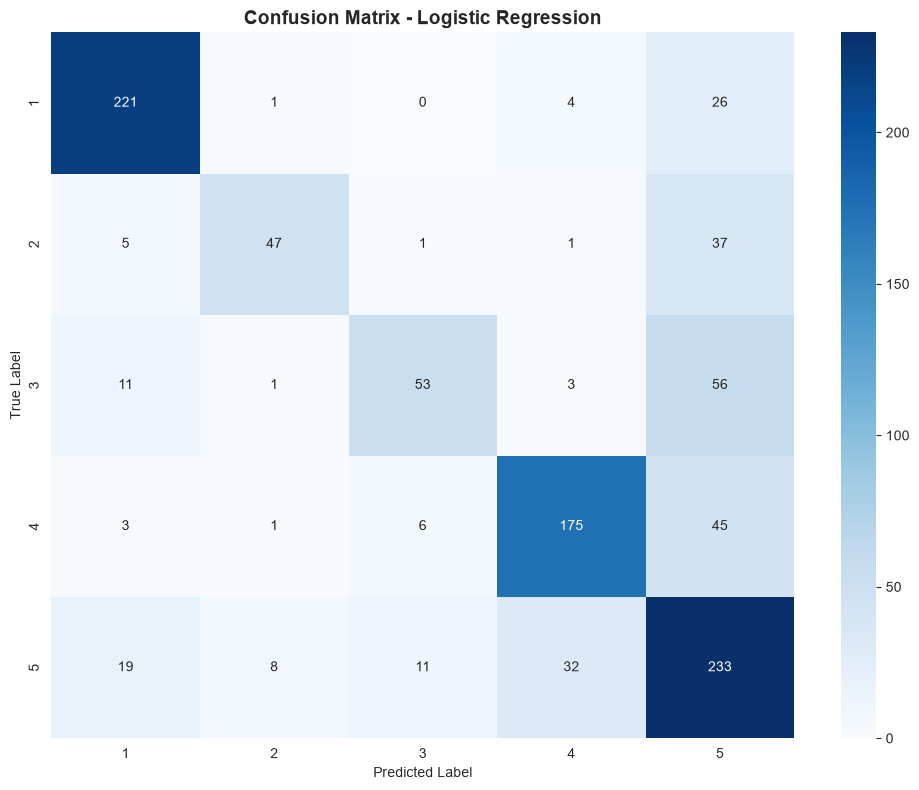

✓ Gráfico salvo em: reports/figures/04_confusion_matrix_lr.png


In [8]:
# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_test_pred_lr)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_confusion_matrix_lr.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico salvo em: reports/figures/04_confusion_matrix_lr.png")

## 9. Métricas Detalhadas - Naive Bayes

In [9]:
print("="*80)
print("MULTINOMIAL NAIVE BAYES")
print("="*80)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_nb, digits=4))

# Resumo de métricas
metrics_nb = {
    'Accuracy': accuracy_score(y_test, y_test_pred_nb),
    'Precision (macro)': precision_score(y_test, y_test_pred_nb, average='macro'),
    'Recall (macro)': recall_score(y_test, y_test_pred_nb, average='macro'),
    'F1 Score (macro)': f1_score(y_test, y_test_pred_nb, average='macro')
}

print("\nResumo de Métricas:")
for metric, value in metrics_nb.items():
    print(f"{metric:.<30} {value:.4f}")

MULTINOMIAL NAIVE BAYES

Classification Report (Test Set):
              precision    recall  f1-score   support

           1     0.8073    0.8810    0.8425       252
           2     0.9200    0.2527    0.3966        91
           3     0.7568    0.2258    0.3478       124
           4     0.7448    0.7739    0.7591       230
           5     0.5307    0.7426    0.6190       303

    accuracy                         0.6760      1000
   macro avg     0.7519    0.5752    0.5930      1000
weighted avg     0.7131    0.6760    0.6537      1000


Resumo de Métricas:
Accuracy...................... 0.6760
Precision (macro)............. 0.7519
Recall (macro)................ 0.5752
F1 Score (macro).............. 0.5930


## 10. Confusion Matrix - Naive Bayes

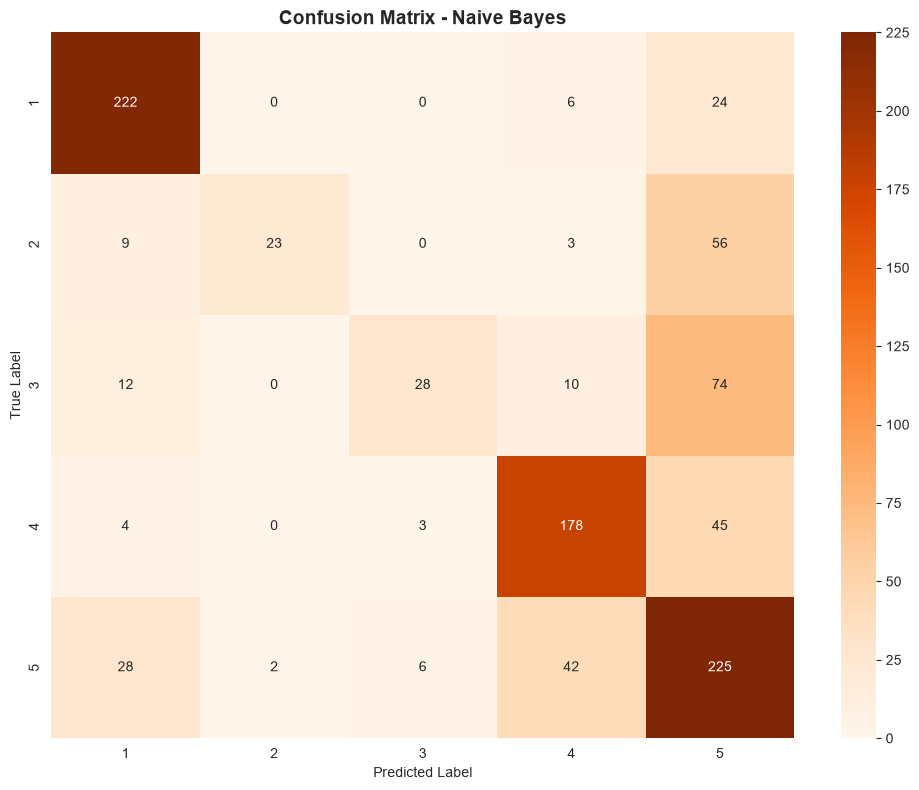

✓ Gráfico salvo em: reports/figures/05_confusion_matrix_nb.png


In [10]:
# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_test_pred_nb)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', cbar=True,
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.title('Confusion Matrix - Naive Bayes', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_confusion_matrix_nb.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico salvo em: reports/figures/05_confusion_matrix_nb.png")

## 11. Comparação de Modelos


COMPARAÇÃO DE MODELOS
                   Logistic Regression  Naive Bayes
Accuracy                        0.7290       0.6760
Precision (macro)               0.7622       0.7519
Recall (macro)                  0.6701       0.5752
F1 Score (macro)                0.6983       0.5930


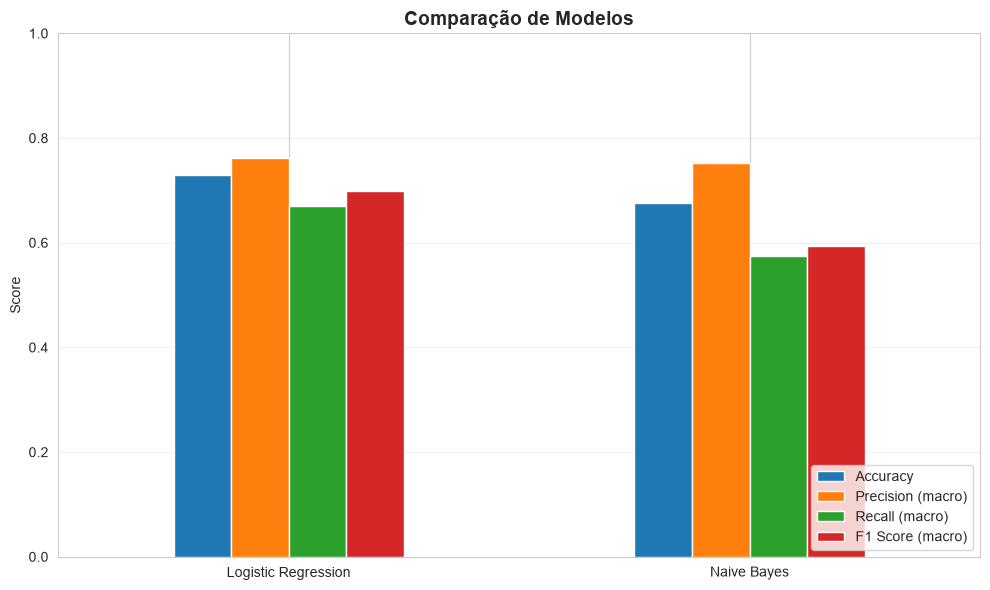

✓ Gráfico salvo em: reports/figures/06_model_comparison.png


In [11]:
# Comparar modelos
comparison_df = pd.DataFrame({
    'Logistic Regression': metrics_lr,
    'Naive Bayes': metrics_nb
})

print("\n" + "="*80)
print("COMPARAÇÃO DE MODELOS")
print("="*80)
print(comparison_df.round(4))

# Visualizar comparação
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.T.plot(kind='bar', ax=ax)
ax.set_title('Comparação de Modelos', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim([0, 1])
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico salvo em: reports/figures/06_model_comparison.png")

## 12. Feature Importance (Top Features)

Top 20 features mais discriminativas (Logistic Regression):
  cancer                              2.1067
  tumor                               1.7400
  carcinoma                           1.7382
  hypertension                        1.3846
  tumors                              1.3509
  brain                               1.2412
  myocardial                          1.2141
  heart                               1.1919
  cell                                1.0894
  cholesterol                         1.0795
  coronary                            1.0661
  cardiac                             1.0528
  liver                               1.0475
  ventricular                         1.0334
  gastric                             1.0144
  artery                              1.0128
  cerebral                            1.0127
  headache                            0.9920
  malignant                           0.9739
  cirrhosis                           0.9719


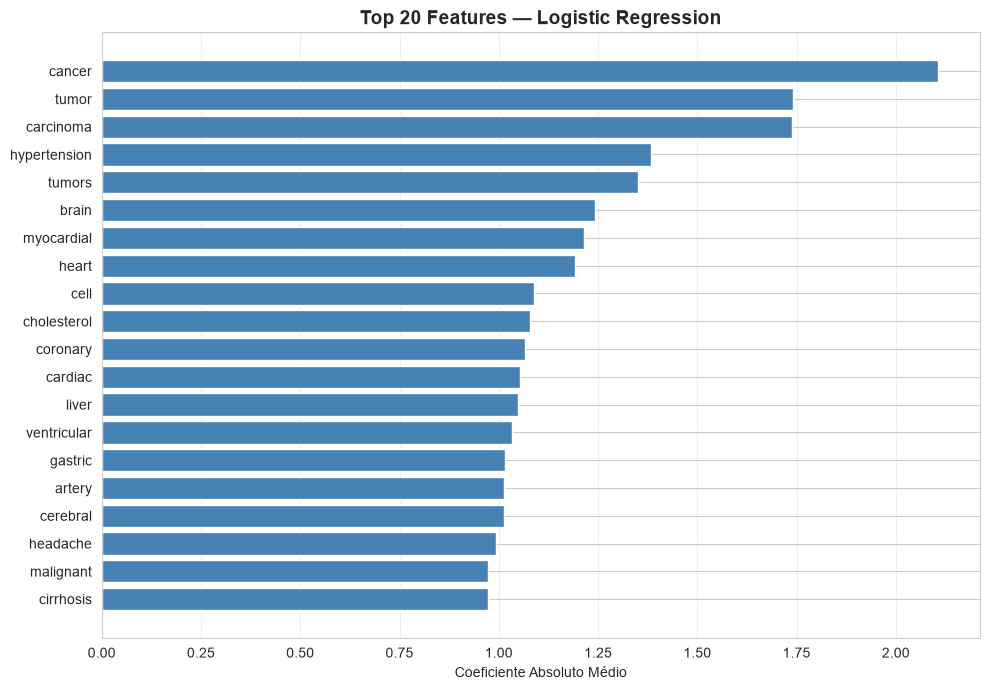

✓ Salvo: reports/figures/07_top_features.png


In [12]:
feature_names = vectorizer.get_feature_names_out()

# Top 20 features por coeficiente absoluto médio entre todas as classes
mean_abs_coef = np.abs(lr_model.coef_).mean(axis=0)
top_idx = mean_abs_coef.argsort()[-20:][::-1]
top_features = feature_names[top_idx]
top_scores = mean_abs_coef[top_idx]

print("Top 20 features mais discriminativas (Logistic Regression):")
for feat, score in zip(top_features, top_scores):
    print(f"  {feat:<35} {score:.4f}")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(top_features)), top_scores[::-1], color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features[::-1], fontsize=10)
ax.set_xlabel('Coeficiente Absoluto Médio')
ax.set_title('Top 20 Features — Logistic Regression', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_top_features.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Salvo: reports/figures/07_top_features.png")

## 13. Resumo Executivo

In [13]:
print("\n" + "="*80)
print("RESUMO EXECUTIVO")
print("="*80)

print("\n📊 BASELINE MODELS:")
print(f"  • Logistic Regression Accuracy: {metrics_lr['Accuracy']:.4f}")
print(f"  • Naive Bayes Accuracy: {metrics_nb['Accuracy']:.4f}")

best_model = 'Logistic Regression' if metrics_lr['Accuracy'] > metrics_nb['Accuracy'] else 'Naive Bayes'
print(f"\n✓ Melhor modelo: {best_model}")

print("\n📈 PRÓXIMAS ETAPAS:")
print("  1. Experimentar deep learning (LSTM, BERT)")
print("  2. Otimização de hiperparâmetros (GridSearch/RandomSearch)")
print("  3. Análise de erros (erros comuns entre labels)")
print("  4. Técnicas de balanceamento de dados")
print("  5. Validação cruzada e ensemble methods")

print("\n✅ Artefatos salvos:")
print("  • Confusion matrices")
print("  • Gráficos comparativos")
print("  • Feature importance")
print("\n" + "="*80)


RESUMO EXECUTIVO

📊 BASELINE MODELS:
  • Logistic Regression Accuracy: 0.7290
  • Naive Bayes Accuracy: 0.6760

✓ Melhor modelo: Logistic Regression

📈 PRÓXIMAS ETAPAS:
  1. Experimentar deep learning (LSTM, BERT)
  2. Otimização de hiperparâmetros (GridSearch/RandomSearch)
  3. Análise de erros (erros comuns entre labels)
  4. Técnicas de balanceamento de dados
  5. Validação cruzada e ensemble methods

✅ Artefatos salvos:
  • Confusion matrices
  • Gráficos comparativos
  • Feature importance

